## 2.7.1 Missing Value Analysis across NorthStar Datasets

In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================================
# Upload ZIP to Colab
# ============================================

from google.colab import files

uploaded = files.upload()


Saving northstar_dataset.zip to northstar_dataset.zip


In [5]:
# ============================================
# Extract ZIP file
# ============================================

import zipfile
import os

zip_path = "northstar_dataset.zip"
extract_path = "northstar_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [11]:
# ============================================
# Check extracted folder
# ============================================

import os

os.listdir("northstar_dataset/northstar_dataset")

['README.txt',
 'data_dictionary.csv',
 'drivers.csv',
 'incidents.csv',
 'customers.csv',
 'orders.csv',
 'complaints.csv',
 'deliveries.csv',
 'hubs.csv',
 'vehicles.csv',
 'app_events.csv']

In [12]:
# ============================================
# Load Datasets
# ============================================

import pandas as pd

base_path = "northstar_dataset/northstar_dataset"

customers = pd.read_csv(f"{base_path}/customers.csv")
orders = pd.read_csv(f"{base_path}/orders.csv")
deliveries = pd.read_csv(f"{base_path}/deliveries.csv")
drivers = pd.read_csv(f"{base_path}/drivers.csv")
vehicles = pd.read_csv(f"{base_path}/vehicles.csv")
hubs = pd.read_csv(f"{base_path}/hubs.csv")
incidents = pd.read_csv(f"{base_path}/incidents.csv")
complaints = pd.read_csv(f"{base_path}/complaints.csv")
app_events = pd.read_csv(f"{base_path}/app_events.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [18]:
# ============================================
# STORE DATASETS IN DICTIONARY
# ============================================

datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "incidents": incidents,
    "complaints": complaints,
    "app_events": app_events
}

In [14]:
# ============================================
# COLUMN LEVEL MISSING VALUES
# ============================================

print("COLUMN LEVEL MISSING VALUES\n")

for name, df in datasets.items():

    print("\n============================")
    print(name.upper())
    print("============================")

    print(df.isnull().sum())

COLUMN LEVEL MISSING VALUES


CUSTOMERS
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64

ORDERS
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

DELIVERIES
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
pro

In [15]:
# ============================================
# DATASET LEVEL MISSING SUMMARY
# ============================================

missing_summary = []

for name, df in datasets.items():

    total_missing = df.isnull().sum().sum()
    missing_percent = (total_missing / (df.size)) * 100

    missing_summary.append({
        "Dataset": name,
        "Total Missing Values": total_missing,
        "Missing Percentage (%)": round(missing_percent, 2)
    })

missing_df = pd.DataFrame(missing_summary)
missing_df

,Dataset,Total Missing Values,Missing Percentage (%)
0,customers,33,0.56
1,orders,25,0.18
2,deliveries,33,0.27
3,drivers,7,0.51
4,vehicles,4,0.42
5,hubs,0,0.00
6,incidents,17,0.87
7,complaints,16,0.50
8,app_events,144,2.25


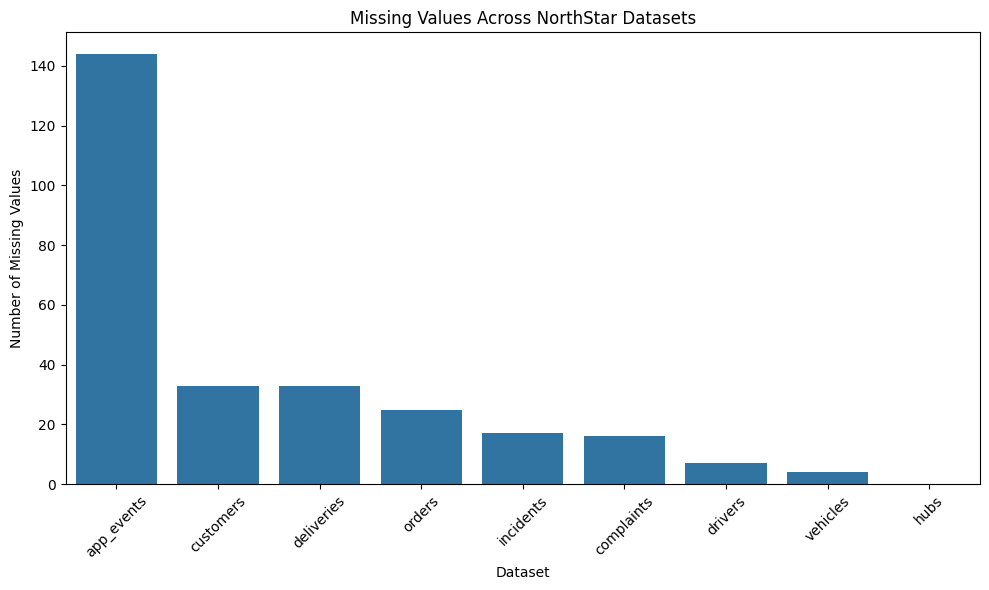

In [20]:
# ============================================
# VISUALIZATION
# ============================================

# Sort data for better visualization
missing_df_sorted = missing_df.sort_values("Total Missing Values", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=missing_df_sorted,
    x="Dataset",
    y="Total Missing Values"
)

plt.title("Missing Values Across NorthStar Datasets")
plt.xlabel("Dataset")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Interpretation

The analysis shows that missing values are present across multiple datasets, with the highest concentration observed in the app_events dataset. This indicates gaps in event-to-order linkage within the system. Moderate missing values are also present in operational datasets such as deliveries, complaints, and incidents, which may impact service performance evaluation and analytics reliability. Overall, core transactional tables remain largely complete, suggesting strong structural data integrity across the system.